## 🔥 Advanced API

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/distributed_graph_flow/blob/main/doc/docs/tutorial/getting_started_advanced_api.ipynb)

The GF Advanced API is a modular, composable collection of low-level primitives
engineered for GNN experts and ML engineers. GF also works as a pick-and-choose
library. You can combine GF primitives with primitives from other ML libraries,
as well as integrate your own custom code.

This tutorial provides an end-to-end implementation of an **in-process** GNN
pipeline using the GF Advanced API. You will learn to ingest graph data, compute
graph samples, normalize features, define a GNN JAX/FLAX model architecture
using low-level primitives, and train, evaluate and export this model for
production.

This tutorial covers essentially the same functionality as the Simple API
tutorial, but with a more detailed and verbose path.

**Prerequisites:**

-   If you are new to GF, read the
    [Getting Started (Simple API) tutorial](tutorial/getting_started_simple_api.md)
    first.
-   You are familiar with JAX, GNN, and Neural Networks in general.

**Notes**

-   Check the 🐜
    [API](/api) for
    more details / examples about specific functions.

## Installing GF

DGF is installed with `pip install dgf -U`.

## Importing libraries

In [1]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

from itertools import islice
import random
import tempfile
import dgf
import flax.linen as nn
import jax
import jax.numpy as jnp
import jaxtyping
import matplotlib.pyplot as plt
import numpy as np
import optax

## Download a graph

The core of GF is the `dgf.data.InMemoryGraph` python dataclass. It is
logic-less dataclass containing Numpy arrays. It is generally paired with a
`dgf.data.GraphSchema`, another dataclass that defines the graph's structure.

GF can ingest data directly from graph repositories like OGB. This tutorial uses
the OGB Arxiv graph:

In [2]:
# Download the arxiv graph from the OGB repo.
graph, schema = dgf.io.fetch_ogb_graph("arxiv")

Caching arxiv graph at /tmp/gf_fetch/arxiv.cache
OGB dependency not available. Downloading graph from CNS.


**Note:** You can replace "arxiv" with "mag" to make this tutorial more
interesting (larger dataset, more nodesets and edgesets).

GF primary way to store graphs on disk is the
[GF Graph format](https://g3doc.corp.google.com/third_party/py/dgf/g3doc/file_formats.md?cl=head).
It is a highly IO efficient, open-sourced, distributable format.

You can load the Arxiv dataset from the GF Graph format with (which is what the
`fetch_ogb_graph` above likely did):

```python
graph, schema = dgf.io.read_graph("/.../ogb_arxiv")
```

GF also has importers and exporters to popular on-disk / remote graph formats such
as Graph AI, TF-GNN, Spanner Graph, BigQuery Graph. You can find the full list
in the `dgf.io.*` and `dgf.beam.io.*` modules.

Finally, GF also has converters to different python-object graph representations
such as other graph libraries representations (e.g., Sparse Deferred, TF-GNN) or
format with different properties (e.g., `dgf.data.JaxInMemoryGraph`). You can
find the full list in the `dgf.convert.*` module.

--------------------------------------------------------------------------------

**For Graph AI users:**

The GF Grpah format is an evolution of the
[Graph AI HGraph format](https://g3doc.corp.google.com/third_party/py/dgf/g3doc/file_formats.md#graph-ai-hgraph).
Conversion from Graph AI Format to GF format can be done in process as simply
as:

```python
graph, schema = dgf.io.read_graphai_hgraph(...)
dgf.io.write_graph(graph, schema)
```

Or, using the distributed CLI
[convert_hgraph_to_gf_graph](https://source.corp.google.com/piper///depot/google3/third_party/py/dgf/examples/convert_hgraph_to_gf_graph.py)
for large graphs.

--------------------------------------------------------------------------------

**For users with large graphs:**

This tutorial only cover in-process operations. For large graphs, GF support
equivalent distributed representations e.g., `dgf.beam.data.Graph` and
`dgf.beam.io.read_graph`.

--------------------------------------------------------------------------------

Before any operations, looking / validating your data is critical.

In [3]:
# Validate the schema and the graph
dgf.validate.validate_graph(graph, schema)

**Remark:** Almost all GF objects are pure dataclasses without checking logic. If
you modify / create them yourself, don't forget to validate them.

In [4]:
# Show the schema
dgf.analyse.print_schema(schema)

Graph Schema:

Node Sets:
  nodes:
    | Feature   | Format     | Semantic    | Shape   | Num cat. vals   |
    |-----------|------------|-------------|---------|-----------------|
    | #id       | BYTES      | PRIMARY_ID  | None    | None            |
    | #split    | BYTES      | CATEGORICAL | None    | None            |
    | feat      | FLOAT_32   | EMBEDDING   | (128,)  | None            |
    | labels    | INTEGER_64 | CATEGORICAL | None    | 40              |
    | year      | INTEGER_64 | NUMERICAL   | None    | None            |


Edge Sets:
  edges: (Source: nodes, Target: nodes)
    (No features)



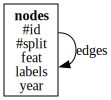

In [5]:
# Plot the schema
dgf.plot.plot_schema(schema)

**Note:** The Arxiv graph is too large to be plotted with `dgf.plot.plot_graph`.
However, we will later plot graph samples.

## More remarks about graph schemas in GF

1.  Many functions take a `dgf.data.GraphSchema` as input. In most of your code,
    you will handle a graph and its related schema.

2.  When a GF function consumes a graph+schema, only the nodesets / edgesets /
    features in the schema are considered. For example, if you only want to
    process / import / export some nodesets, you'll generally make a copy of the
    schema (cheap), remove the unused nodsets, and call GF on this modified
    schema.

3.  The `dgf.data.GraphSchemaFilter` is an alternative to modifying schema
    manually. It is espetially useful for readers / importers functions.

4.  Each feature in a schema has two importance fields:

-   The `format` defines how the feature is stored e.g. int32, float64, bytes.
-   The `semantic` defines how the feature should be interpreted e.g.
    categorical, numerical, embedding, date, primary key.

While only a subset of GF methods use the semantic feature, configuring it
correctly from the start can save you a lot of time. For instance, it is used by
mid-level tools to automatize data normalization.

## Graph Sampling

While the arXiv dataset does not need it, our next step is to generate graph
samples.

In [6]:
# Create a graph sampling configuration.
plan = dgf.sampling.SimpleSamplingConfig(
    seed_nodeset="nodes",
    # Maximum distances to consider.
    num_hops=1,
    # How many neighbors we consider at each hop.
    hop_width=5,
    # Follow the edges on both directions.
    reverse=True,
)

# Create a graph sampler / index the graph.
sampler = dgf.sampling.create_sampler(
    graph=graph,
    plan=plan,
    schema=schema,
    batch_size=32,
)

**Remarks:**

-   For more control, specify a `dgf.sampling.SamplingPlan` instead of a
    `dgf.sampling.SimpleSamplingConfig`.
-   GF has functions to convert SamplingPlan from/to TFGNN Sampling specs.

We can then generate a single sample as:

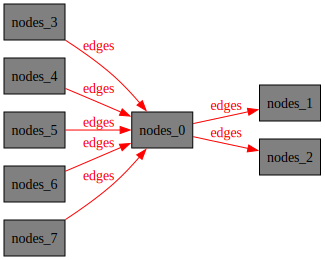

In [7]:
# Generate a graph
sample = sampler.sample(seed_node_idxs=0)

# Plot the sample
dgf.plot.plot_graph(sample, schema, features=False)

You can also generate a set of samples (this is multi-threaded).

In [8]:
samples = sampler.sample(seed_node_idxs=[0, 1, 2])
print(f"Generated {len(samples)} samples")

Generated 3 samples


The `merge` method can be used to merge multiple graph samples together
(optionally with padding):

In [9]:
merged_samples, merge_offsets = dgf.transform.merge_graphs(
    graphs=samples, schema=schema, padding=None, sentinel_offset=False
)

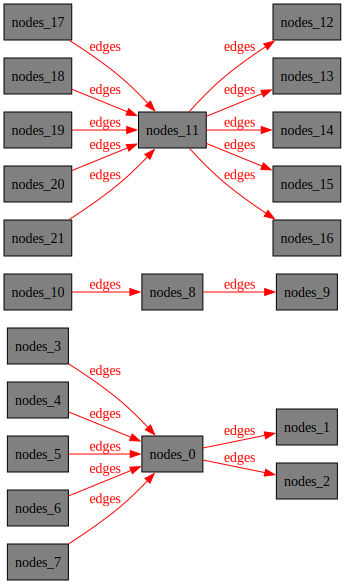

In [10]:
dgf.plot.plot_graph(merged_samples, schema, features=False)

The `merge_offsets` contains the starting indices of each nodeset and each
original graph in the merge graph. Since we call it with
`sentinel_offset=False`, `merge_offsets` does not include the offset of the
sentinel nodes.

In [11]:
merge_offsets

{'nodes': array([ 0,  8, 11])}

Let's split the nodes into a training and validation set.

In [12]:
num_nodes = graph.node_sets["nodes"].num_nodes
all_seed_node_idxs = np.arange(num_nodes)
np.random.seed(42)
np.random.shuffle(all_seed_node_idxs)
num_valid = int(num_nodes * 0.2)  # Keep 20% of the nodes for validation
valid_seed_node_idxs = all_seed_node_idxs[:num_valid]
train_seed_node_idxs = all_seed_node_idxs[num_valid:]
print("Num train nodes:", len(train_seed_node_idxs))
print("Num valid nodes:", len(valid_seed_node_idxs))

Num train nodes: 135475
Num valid nodes: 33868


The `dgf.transform.batch_indices_generator` function is useful to generate seed
indices:

In [13]:
# Generate 3 batches, each containing 5 seed-node indices.
for seed_node_idxs in islice(
    dgf.transform.batch_indices_generator(
        train_seed_node_idxs, batch_size=5, drop_remainder=True, shuffle=False
    ),
    3,
):
  print(seed_node_idxs)

[  1895  44513  24828 122605 140271]
[ 19815   8619 107350  93409  12795]
[ 69167  69552 143796 129899  59454]


We can combine all of this together to define a graph sample python generator.

In [14]:
def batch_generator(
    seed_node_idxs, padding=None, also_return_merge_offsets=False, batch_size=32
):
  """Generates batched merged graphs samples, and (optional) merging offsets."""
  for seed_node_idxs in dgf.transform.batch_indices_generator(
      seed_node_idxs, batch_size=batch_size, drop_remainder=True, shuffle=False
  ):
    # Sample the graphs
    samples = sampler.sample(seed_node_idxs.tolist())

    try:
      # Merge the graph samples into a single graph.
      merged_samples, merge_offsets = dgf.transform.merge_graphs(
          graphs=samples,
          schema=schema,
          padding=padding,
          sentinel_offset=False,
      )
    except dgf.exception.InsufficientPaddingError:
      # Skip if the number of nodes is too large for the padding.
      continue

    if also_return_merge_offsets:
      yield merged_samples, merge_offsets
    else:
      yield merged_samples


# Generate 5 batches of graphs.
for graph_sample in islice(batch_generator(train_seed_node_idxs), 5):
  print(
      "Number of nodes and edges in the sample:",
      graph_sample.node_sets["nodes"].num_nodes,
      graph_sample.edge_sets["edges"].num_edges(),
  )

Number of nodes and edges in the sample: 205 175
Number of nodes and edges in the sample: 192 163
Number of nodes and edges in the sample: 199 169
Number of nodes and edges in the sample: 217 185
Number of nodes and edges in the sample: 178 146


**Remark:**

-   Many GF functions consume / return graph generators.

We can use our graph generator to determine the optimal padding (since JAX does
not support variable length arrays).

In [15]:
padding = dgf.analyse.padding_from_graph_generator(
    schema=schema, graphs=islice(batch_generator(train_seed_node_idxs), 200)
)
padding

Padding(node_sets={'nodes': NodeSetPadding(num_nodes=260)}, edge_sets={'edges': EdgeSetPadding(num_edges=226)})

If we apply the padding, all the batches have the same number of nodes and
edges. Sentinel nodes and edges are added.

In [16]:
# Now, all the batches of graph samples have the same number of nodes.
for graph_sample in islice(
    batch_generator(train_seed_node_idxs, padding=padding), 5
):
  print(
      "Number of nodes and edges in the sample:",
      graph_sample.node_sets["nodes"].num_nodes,
      graph_sample.edge_sets["edges"].num_edges(),
  )

Number of nodes and edges in the sample: 260 226
Number of nodes and edges in the sample: 260 226
Number of nodes and edges in the sample: 260 226
Number of nodes and edges in the sample: 260 226
Number of nodes and edges in the sample: 260 226


## Data normalization

To be processed by neural networks, features must be normalized (unless they are
pre-normalized, like embeddings). GF provides several normalization utility
primitives to help manage data with varying levels of control.

The primary goal of normalization is to make the data compatible with neural
nets. For instance, numerical features are generally scaled (e.g., using soft
quantiles), while categorical string features are mapped to integers using a
dictionary.

We will begin by computing statistics for all features

In [17]:
feature_stats = dgf.analyse.feature_statistics_from_graphs(
    graphs=islice(batch_generator(train_seed_node_idxs), 200),
    schema=schema,
)
feature_stats

GraphFeatureStatistics:
  Node Sets (1):
    'nodes':
      '#id': count=38765, min=nan, max=nan
      '#split': count=38765, min=nan, max=nan, dictionary=(3)['train': 25200, 'test': 8187, 'valid': 5378]
      'feat': count=38765, min=nan, max=nan
      'labels': count=38765, min=0.0000, max=39.0000
      'year': count=38765, min=1971.0000, max=2020.0000, quantiles=(100)[1971.0000, 2002.0000, 2006.0000, ..., 2020.0000, 2020.0000, 2020.0000]

**Remarks:**

-   We compute statistics in-process. For large datasets, distributed
    computation of feature statistics might be better.
-   Don't use padding for the feature statistics.
-   GF allows you both to compute statistics on graph samples or on the original
    graph.
-   The statistics are computed according to the `semantic` and `format` of the
    schema. For example, quantile statistics are not computed on the `feat`
    numerical column because it is has a `semantic=EMBEDDING`.

The statistics can be used to instantiate normalization blocks.

In [18]:
normalizer = dgf.transform.auto_normalize(schema=schema, stats=feature_stats)
normalizer

[Warning] No normalizer created for node set 'nodes', feature '#id'.


GraphNormalizer(config=GraphNormalizerConfig(nodesets={'nodes': NodeSetNormalizerConfig(normalizers=[DictionaryIndexNormalizer(input_feature='#split', type='DictionaryIndexNormalizer', dictionary_map={'train': 0, 'test': 1, 'valid': 2}, out_of_vocab_value=3, output_shape=None, output_feature_name='#split_INDEX', tf_table=None), IdentityNormalizer(input_feature='labels', type='IdentityNormalizer', input_schema=FeatureSchema(format=<FeatureFormat.INTEGER_64: 'INTEGER_64'>, semantic=<FeatureSemantic.CATEGORICAL: 'CATEGORICAL'>, shape=None, num_categorical_values=40, is_utf8_string=False)), SoftQuantileNormalizer(input_feature='year', type='SoftQuantileNormalizer', output_feature_name='year_SOFT_QUANTILE', output_shape=None, quantiles=array([1971., 2002., 2006., 2007., 2008., 2009., 2010., 2011., 2012.,
       2013., 2014., 2015., 2016., 2017., 2018., 2019., 2020.],
      dtype=float32)), IdentityNormalizer(input_feature='feat', type='IdentityNormalizer', input_schema=FeatureSchema(format=

**Remarks:**

-   Instead of the auto-normalization, you can define the normalization
    operations manually e.g. `dgf.transform.SoftQuantileNormalizer`.

You can check individual normalization blocks:

In [19]:
# The "year" feature is normalized with the SoftQuantileNormalizer.
normalizer.config.nodesets["nodes"].normalizers[2]

SoftQuantileNormalizer(input_feature='year', type='SoftQuantileNormalizer', output_feature_name='year_SOFT_QUANTILE', output_shape=None, quantiles=array([1971., 2002., 2006., 2007., 2008., 2009., 2010., 2011., 2012.,
       2013., 2014., 2015., 2016., 2017., 2018., 2019., 2020.],
      dtype=float32))

In [20]:
# The "feat" feature is an embedding, so it is transmitted without modification (identity normalizer).
normalizer.config.nodesets["nodes"].normalizers[3]

IdentityNormalizer(input_feature='feat', type='IdentityNormalizer', input_schema=FeatureSchema(format=<FeatureFormat.FLOAT_32: 'FLOAT_32'>, semantic=<FeatureSemantic.EMBEDDING: 'EMBEDDING'>, shape=(128,), num_categorical_values=None, is_utf8_string=False))

You can obtain the output schema of the normalizer:

In [21]:
dgf.analyse.print_schema(normalizer.output_schema())

Graph Schema:

Node Sets:
  nodes:
    | Feature            | Format     | Semantic    | Shape   | Num cat. vals   |
    |--------------------|------------|-------------|---------|-----------------|
    | #split_INDEX       | INTEGER_64 | CATEGORICAL | None    | 4               |
    | feat               | FLOAT_32   | EMBEDDING   | (128,)  | None            |
    | labels             | INTEGER_64 | CATEGORICAL | None    | 40              |
    | year_SOFT_QUANTILE | FLOAT_32   | EMBEDDING   | None    | None            |


Edge Sets:
  edges: (Source: nodes, Target: nodes)
    (No features)



You can run the normalizer:

In [22]:
raw_batch = next(batch_generator(train_seed_node_idxs, batch_size=2))
normalized_batch = normalizer.normalize_numpy(raw_batch)
normalized_batch

InMemoryGraph(node_sets={'nodes': InMemoryNodeSet(num_nodes=260, features={'#split_INDEX': array([0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 2, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 2, 0,
       0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 0, 2, 2, 0, 2, 2, 2,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]), 'labels': array([29, 34, 29, 35,  8, 34,  8

In the next section, we use JAX and Flax to define and train our model. Our
`normalized_batch` object (`dgf.data.InMemoryGraph`) is made of NumPy arrays. We
can convert it into an equivalent representation with JAX arrays instead:

In [23]:
type(normalized_batch.edge_sets["edges"].adjacency)

numpy.ndarray

In [24]:
jax_normalized_batch = dgf.convert.graph_to_jax_graph(normalized_batch)
type(jax_normalized_batch.edge_sets["edges"].adjacency)

jax.jaxlib._jax.ArrayImpl

## Core model definition and training

Let's define and train a FLAX module for our graph.

**Note:** We use the `dgf.jax.train` simple FLAX training loop:

In [25]:
class Model(nn.Module):
  schema: dgf.data.GraphSchema
  num_label_classes: int

  @nn.compact
  def __call__(
      self, batch: tuple[dgf.data.JaxInMemoryGraph, jnp.ndarray], training: bool
  ):
    print("...Tracing model")
    graph, seed_node_idxs = batch

    # Embed features into a single embedding per nodeset.
    embedder_config = dgf.jax.layers.EmbedGraphConfig()
    embedder = embedder_config.make(schema=self.schema)
    embedded_output_schema = embedder_config.output_schema(self.schema)
    graph = embedder(graph, training=training)

    # A MLP layer on each nodeset independently. This also ensure that all the
    # nodeset embeddings have the same size.
    for _, nodeset_value in graph.node_sets.items():
      mlp = dgf.jax.layers.ResidualMLPV2Config(
          dims=128, norm="layer_norm", residual=False
      ).make()
      nodeset_value.features["embedding"] = mlp(
          nodeset_value.features["embedding"]
      )

    # Message passing between nodes
    for _ in range(2):
      message_passer = dgf.jax.layers.HeterogeneousGraphConvolutionConfig(
          dims=128
      ).make(embedded_output_schema)
      graph = message_passer(graph, training=training)

    # Extract embedding of seed nodes
    node_embedding = graph.node_sets["nodes"].features["embedding"][
        seed_node_idxs
    ]

    logits = nn.Dense(num_label_classes)(node_embedding)
    return logits


# The model received the normalized schema, without the label column.
model_schema = normalizer.output_schema()
num_label_classes = (
    model_schema.node_sets["nodes"].features["labels"].num_categorical_values
)
del model_schema.node_sets["nodes"].features["labels"]

# Instantiate the model
model = Model(schema=model_schema, num_label_classes=num_label_classes)


# The model loss
def loss_fn(
    params: jaxtyping.PyTree,
    batch: jaxtyping.PyTree,
    labels: jnp.ndarray,
    rng_key: jnp.ndarray | None,
    training: bool,
) -> jnp.ndarray | jaxtyping.PyTree:
  if rng_key is not None:
    rngs = {"dropout": rng_key}
  else:
    rngs = None
  logits = model.apply(params, batch, training=training, rngs=rngs)
  loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
  accuracy = jnp.argmax(logits, axis=-1) == labels
  return jnp.mean(loss), {"accuracy": accuracy.mean()}


# The model training step
@jax.jit
def train_step(params, opt_state, batch, rng_key):
  graph, seed_node_idxs = batch
  labels = graph.node_sets["nodes"].features["labels"][seed_node_idxs]
  (loss, aux_data), grads = jax.value_and_grad(loss_fn, has_aux=True)(
      params, batch, labels, rng_key, True
  )
  updates, opt_state = opt.update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state, {"loss": loss, **aux_data}


# The model validation step
@jax.jit
def valid_step(params, opt_state, batch):
  graph, seed_node_idxs = batch
  labels = graph.node_sets["nodes"].features["labels"][seed_node_idxs]
  loss, aux = loss_fn(params, batch, labels, None, False)
  return {"loss": loss, **aux}


# Process a batch of data before sending it to the model.
def process_batch(
    graph: dgf.data.InMemoryGraph,
    merge_offsets: dict[str, np.ndarray],
):
  normalized_graph = normalizer.normalize_numpy(graph)
  jax_normalized_graph = dgf.convert.graph_to_jax_graph(normalized_graph)
  seed_node_idxs = jnp.asarray(merge_offsets["nodes"])
  return jax_normalized_graph, seed_node_idxs


# Generate the training data
def infinite_train_dataset_iterator():
  while True:
    for raw_batch, merge_offsets in batch_generator(
        train_seed_node_idxs,
        batch_size=32,
        padding=padding,
        also_return_merge_offsets=True,
    ):
      yield process_batch(raw_batch, merge_offsets)


# Generate the validation data
def finite_valid_dataset_iterator():
  for raw_batch, merge_offsets in batch_generator(
      valid_seed_node_idxs,
      batch_size=32,
      padding=padding,
      also_return_merge_offsets=True,
  ):
    yield process_batch(raw_batch, merge_offsets)


# A basic optimizer
opt = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=0.0001),
)

# Train the model
training_output = dgf.jax.train(
    model=model,
    opt=opt,
    train_step=train_step,
    valid_step=valid_step,
    dataset_iterator=infinite_train_dataset_iterator(),
    valid_dataset_iterator_fn=finite_valid_dataset_iterator,
    num_train_steps=10_000,
    valid_every_n_steps=1000,
    train_log_every_n_steps=100,
    rng_key=jax.random.PRNGKey(42),
    print_logs=True,
)

Generate first batch to initialize model
Create model variables
...Tracing model
Create model variables finished in 9.07 seconds
Will validate model every 1000 step(s)
Will checkpoint model every 1000 step(s)
Start training. The first two steps are generally slow.


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

...Tracing model


Training:  10%|▉         | 983/10000 [00:21<00:40, 224.38it/s, step=1000, train-accuracy=0.5503, train-loss=1.5502]

...Tracing model


...

step:8000 train-accuracy:0.6569 train-loss:1.1270 valid-accuracy:0.6568 valid-loss:1.1213


Training:  90%|█████████ | 9032/10000 [02:25<01:20, 12.07it/s, step=9000, train-accuracy=0.6716, train-loss=1.0878, valid-accuracy=0.6568, valid-loss=1.1213]

step:9000 train-accuracy:0.6716 train-loss:1.0878 valid-accuracy:0.6557 valid-loss:1.1199


Training: 100%|██████████| 10000/10000 [02:30<00:00, 66.33it/s, step=9900, train-accuracy=0.6538, train-loss=1.0974, valid-accuracy=0.6557, valid-loss=1.1199]


step:10000 train-accuracy:0.6538 train-loss:1.0974 valid-accuracy:0.6613 valid-loss:1.1039
Final metrics: {'step': '9900', 'train-accuracy': '0.6538', 'train-loss': '1.0974', 'valid-accuracy': '0.6557', 'valid-loss': '1.1199'}


**Remark:**

-   We use several of the FLAX layers defined in the `dgf.jax.layers.*` module
    (embedder, hetero graph conf, mlp). Advanced users are encouraged to try
    other layers and/or implement they own.
-   This example shows a complex setup with feature normalization and
    multiple-nodesets. A model trained on a single nodeset and with only
    embedding features will be much simpler.
-   Layers are implemented as a config dataclass and a flax module e.g.:

```python
config = dgf.jax.layers.ResidualMLPV2Config()
module : dgf.jax.layers.ResidualMLPV2 = config.make()
x = module(x)
```

-   Sometime the `make` method will require a schema.

The `train` method collects training and validation logs that we can plot:

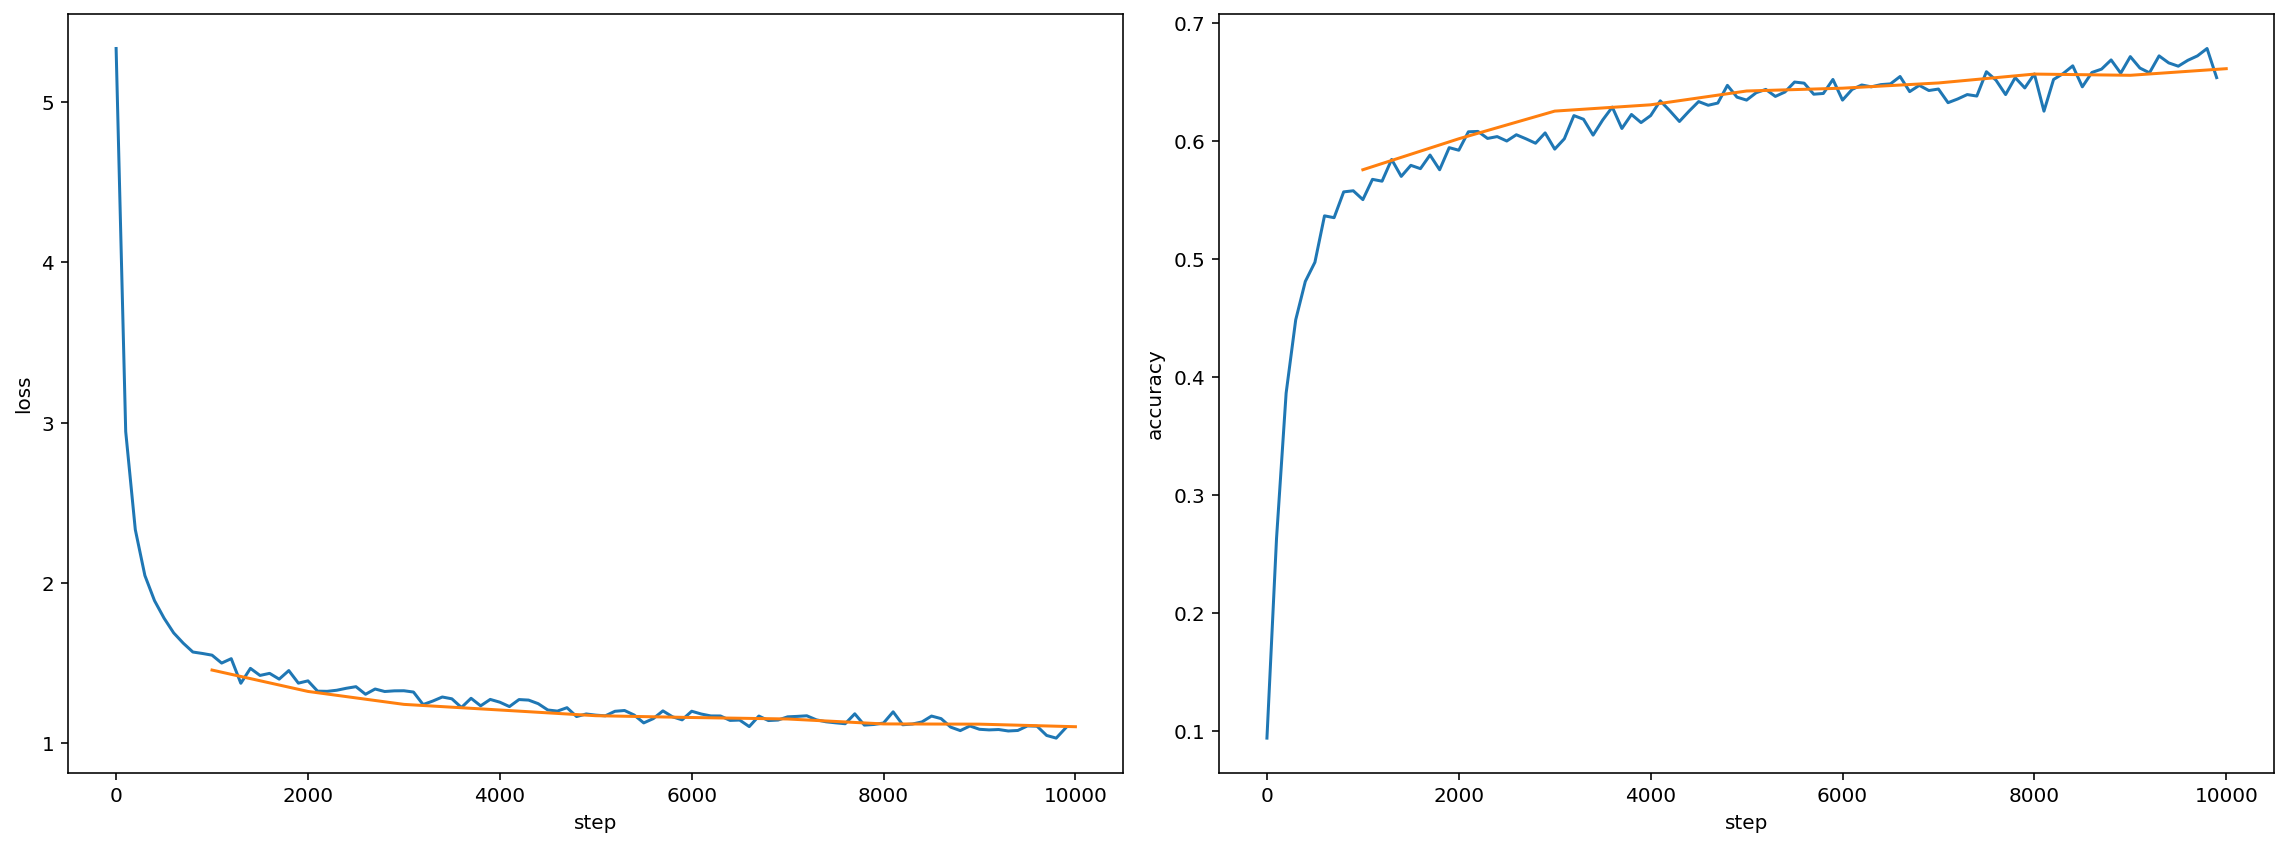

In [26]:
# Plot the training logs.
plt.figure(figsize=(16, 6))


def extract_steps(logs):
  return [log.step for log in logs]


def extract_metric(metric, logs):
  return [log.metrics[metric] for log in logs]


metrics = ["loss", "accuracy"]
for metrix_idx, metric in enumerate(metrics):
  plt.subplot(1, len(metrics), metrix_idx + 1)
  plt.plot(
      extract_steps(training_output.train_logs),
      extract_metric(metric, training_output.train_logs),
      label="train",
  )
  plt.plot(
      extract_steps(training_output.valid_logs),
      extract_metric(metric, training_output.valid_logs),
      label="valid",
  )
  plt.xlabel("step")
  plt.ylabel(metric)


plt.tight_layout()
plt.show()

## Generating Predictions

We can now use our model to make predictions:

In [27]:
# Generate some predictions and compare them to the labels.
@jax.jit
def predict(jax_merged_samples, seed_node_idxs):
  logits = model.apply(
      variables=training_output.model_params,
      batch=(jax_merged_samples, seed_node_idxs),
      training=False,
  )
  probabilities = nn.softmax(logits)
  predicted_class = jnp.argmax(probabilities, axis=-1)
  return predicted_class


for jax_merged_samples, seed_node_idxs in islice(
    finite_valid_dataset_iterator(), 3
):
  predicted_class = predict(jax_merged_samples, seed_node_idxs)
  print("preds:", predicted_class)

  labels = jax_merged_samples.node_sets["nodes"].features["labels"][
      seed_node_idxs
  ]
  print("label:", labels)
  print("==============")

...Tracing model
preds: [24 30 13 26 37 16 30 16 28 28 16  8  9  2  2 28 30 26 28 16 16 16 24  5
 16 24 16 28 24  5 16  8]
label: [24 30 13  3 37 30  6 24 18 19 16 10 28  9  2  8 30 26 28 16 16 16 24 28
 16 24 16 28 10  5 16  8]
preds: [24 16 28 27 28  8 38 16 27 28 25 16 28 26  2 10 24 28 28  4 16 24 30 10
 20 24  5 10 28 23 16 30]
label: [16 16 28 27 25 28 38 16 10 28 25  3 28 26  2 10 24 28 28 36 16 10 30 36
 20  5  5 27 28 23 16 30]
preds: [30 24 16  4 28 16 14 19 28 16 16 28 26  8 30 16 30 30  4 16 24 28 16 24
 27 24 16 24 16 24 34  2]
label: [30 13 16  4 28 16  9 19  8 16 16 28 26 34 30 24 30 30  3 30 28 28 16 24
  6 16 16 30 16 19 34 22]
